In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("quora/question-pairs-dataset")

print("Path to dataset files:", path)

In [4]:
import string
import pandas as pd
import copy
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
pd.read_csv("/root/.cache/kagglehub/datasets/quora/question-pairs-dataset/versions/2/questions.csv")

In [ ]:
df=pd.read_csv("/root/.cache/kagglehub/datasets/quora/question-pairs-dataset/versions/2/questions.csv")
df.head()

In [5]:
df=pd.read_csv("questions.csv")

In [6]:
df1 = copy.deepcopy(df)

In [7]:
df1.columns

Index(['id', 'qid1', 'qid2', 'question1', 'question2', 'is_duplicate'], dtype='object')

In [9]:
df1

,id,qid1,qid2,question1,question2,is_duplicate
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0
3,3,7,8,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0
4,4,9,10,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0
...,...,...,...,...,...,...
404346,404346,789792,789793,How many keywords are there in the Racket prog...,How many keywords are there in PERL Programmin...,0
404347,404347,789794,789795,Do you believe there is life after death?,Is it true that there is life after death?,1
404348,404348,789796,789797,What is one coin?,What's this coin?,0
404349,404349,789798,789799,What is the approx annual cost of living while...,I am having little hairfall problem but I want...,0


In [11]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404351 entries, 0 to 404350
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            404351 non-null  int64 
 1   qid1          404351 non-null  int64 
 2   qid2          404351 non-null  int64 
 3   question1     404350 non-null  object
 4   question2     404349 non-null  object
 5   is_duplicate  404351 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 18.5+ MB


# BOW

In [14]:
new_df = df1.sample(90000)
new_df=new_df.dropna()

In [18]:
ques_df =new_df[['question1','question2']]
ques_df.head()

,question1,question2
229414,Why did Hillary Clinton think it was necessary...,Why did Hillary Clinton use a private server i...
234789,"Identity: In India or otherwise, is there any ...",Can I know which sim card is activated in my m...
171597,What would happen to object if it moves faster...,Is it possible to walk faster than the speed o...
90513,How can I have an orgasm?,"Which one is good: oral, anal, or vaginal sex?"
100505,How can you find historical Second mortgage? |...,"As a web developer, why do you like to develop..."


In [23]:
ques_df=ques_df.dropna()

In [25]:
# Import CountVectorizer to convert text into numerical feature vectors
from sklearn.feature_extraction.text import CountVectorizer

# Combine question1 and question2 into a single list
# This ensures the same vocabulary is learned from both columns
questions = list(ques_df['question1']) + list(ques_df['question2'])

# Create a Bag-of-Words vectorizer
# Keep only the top 3000 most frequent words
cv = CountVectorizer(max_features=3000)

# Learn the vocabulary and transform all questions into vectors
# Shape after transformation:
# (number_of_questions * 2, 3000)
#
# np.vsplit(..., 2) splits the matrix into two equal parts:
# q1_arr -> vectors for question1
# q2_arr -> vectors for question2
q1_arr, q2_arr = np.vsplit(
    cv.fit_transform(questions).toarray(),
    2
)

# Convert question1 vectors into a DataFrame
temp_df1 = pd.DataFrame(q1_arr, index=ques_df.index)

# Convert question2 vectors into a DataFrame
temp_df2 = pd.DataFrame(q2_arr, index=ques_df.index)

# Concatenate both question representations side-by-side
# Final shape becomes:
# (30000, 6000)
# 3000 features from question1 + 3000 features from question2 = 6000
# 30000 Row data  
temp_df = pd.concat([temp_df1, temp_df2], axis=1)

# Display shape of the final feature matrix
temp_df.shape

(89999, 6000)

In [26]:
temp_df

,0,1,2,3,4,5,6,7,8,9,...,2990,2991,2992,2993,2994,2995,2996,2997,2998,2999
229414,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
234789,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
171597,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
90513,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
100505,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
184493,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
316092,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
379565,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
263450,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [27]:
temp_df['is_duplicate'] = df1['is_duplicate']

In [177]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
rf = RandomForestClassifier()
rf.fit(X_train,y_train)
y_pred = rf.predict(X_test)
accuracy_score(y_test,y_pred)

0.7731666666666667

In [178]:
from xgboost import XGBClassifier
xgb = XGBClassifier()
xgb.fit(X_train,y_train)
y_pred = xgb.predict(X_test)
accuracy_score(y_test,y_pred)

0.7338888888888889

-----

----

In [2]:
# We already have 6000 Bag-of-Words features
# (3000 features from Question 1 + 3000 features from Question 2).
#
# Now we are augmenting the feature set with 7 handcrafted features:
# 1. q1_len      -> Character length of Question 1
# 2. q2_len      -> Character length of Question 2
# 3. q1_words    -> Number of words in Question 1
# 4. q2_words    -> Number of words in Question 2
# 5. word_common -> Number of common unique words between Q1 and Q2
# 6. word_total  -> Total number of words in Q1 and Q2
# 7. word_share  -> word_common / word_total
#
# Final feature dimension:
# 6000 (BoW features) + 7 (engineered features) = 6007 features

###  Feature Engineering

In [28]:
#1. q1_len      -> Character length of Question 1
new_df["q1_len"]=new_df["question1"].str.len()

# 2. q2_len      -> Character length of Question 2
new_df["q2_len"]=new_df["question2"].str.len()

In [29]:
new_df

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len
229414,229414,452092,452093,Why did Hillary Clinton think it was necessary...,Why did Hillary Clinton use a private server i...,1,125,64
234789,234789,462569,462570,"Identity: In India or otherwise, is there any ...",Can I know which sim card is activated in my m...,0,127,72
171597,171597,339068,339069,What would happen to object if it moves faster...,Is it possible to walk faster than the speed o...,0,67,54
90513,90513,179716,179717,How can I have an orgasm?,"Which one is good: oral, anal, or vaginal sex?",0,25,46
100505,100505,199434,199435,How can you find historical Second mortgage? |...,"As a web developer, why do you like to develop...",0,69,126
...,...,...,...,...,...,...,...,...
184493,184493,364338,364339,Why doesn't Germany pursues indigenous jet eng...,Why doesn't Germany produce jet engines?,1,62,40
316092,316092,620288,620289,Is forest officer life is a risky life?,What annoys you about actors?,0,39,29
379565,379565,742382,742383,What is the best way to take revenge on my Ex?,What are some good ways to get revenge on some...,0,46,50
263450,263450,518363,518364,What are the movies you must watch once before...,Which are the must watch movies?,1,55,32


In [30]:
# 3. q1_words    -> Number of words in Question 1

new_df['q1_num_words']= new_df["question1"].str.split().apply(lambda x : len(x))

In [31]:
# 4. q2_words    -> Number of words in Question 2

In [32]:
new_df['q2_num_words']= new_df['question2'].apply(lambda row: len(row.split(" ")))

In [33]:
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words
229414,229414,452092,452093,Why did Hillary Clinton think it was necessary...,Why did Hillary Clinton use a private server i...,1,125,64,20,12
234789,234789,462569,462570,"Identity: In India or otherwise, is there any ...",Can I know which sim card is activated in my m...,0,127,72,24,14
171597,171597,339068,339069,What would happen to object if it moves faster...,Is it possible to walk faster than the speed o...,0,67,54,13,11
90513,90513,179716,179717,How can I have an orgasm?,"Which one is good: oral, anal, or vaginal sex?",0,25,46,6,9
100505,100505,199434,199435,How can you find historical Second mortgage? |...,"As a web developer, why do you like to develop...",0,69,126,11,22


In [34]:
# 5. word_common -> Number of common unique words between Q1 and Q2

In [35]:
def common_words(row):
    w1 = set(map(lambda word: word.lower().strip(), row['question1'].split(" ")))
    w2 = set(map(lambda word: word.lower().strip(), row['question2'].split(" ")))    
    return len(w1 & w2)

In [36]:
new_df['word_common'] = new_df.apply(common_words, axis=1)
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common
229414,229414,452092,452093,Why did Hillary Clinton think it was necessary...,Why did Hillary Clinton use a private server i...,1,125,64,20,12,8
234789,234789,462569,462570,"Identity: In India or otherwise, is there any ...",Can I know which sim card is activated in my m...,0,127,72,24,14,6
171597,171597,339068,339069,What would happen to object if it moves faster...,Is it possible to walk faster than the speed o...,0,67,54,13,11,7
90513,90513,179716,179717,How can I have an orgasm?,"Which one is good: oral, anal, or vaginal sex?",0,25,46,6,9,0
100505,100505,199434,199435,How can you find historical Second mortgage? |...,"As a web developer, why do you like to develop...",0,69,126,11,22,1


In [37]:
# 6. word_total  -> Total number of unique words in Q1 and Q2

In [38]:
def unique_words(row):
    w1 = set(map(lambda word: word.lower().strip(), row['question1'].split(" ")))
    w2 = set(map(lambda word: word.lower().strip(), row['question2'].split(" ")))    
    return (len(w1) + len(w2))

In [39]:
new_df['unique_words_total'] = new_df.apply(unique_words, axis=1)
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common,unique_words_total
229414,229414,452092,452093,Why did Hillary Clinton think it was necessary...,Why did Hillary Clinton use a private server i...,1,125,64,20,12,8,31
234789,234789,462569,462570,"Identity: In India or otherwise, is there any ...",Can I know which sim card is activated in my m...,0,127,72,24,14,6,36
171597,171597,339068,339069,What would happen to object if it moves faster...,Is it possible to walk faster than the speed o...,0,67,54,13,11,7,24
90513,90513,179716,179717,How can I have an orgasm?,"Which one is good: oral, anal, or vaginal sex?",0,25,46,6,9,0,15
100505,100505,199434,199435,How can you find historical Second mortgage? |...,"As a web developer, why do you like to develop...",0,69,126,11,22,1,31


In [40]:
# 7. word_share  -> word_common / word_total

In [41]:
new_df['word_share'] = round(new_df['word_common']/new_df['unique_words_total'],2)
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common,unique_words_total,word_share
229414,229414,452092,452093,Why did Hillary Clinton think it was necessary...,Why did Hillary Clinton use a private server i...,1,125,64,20,12,8,31,0.26
234789,234789,462569,462570,"Identity: In India or otherwise, is there any ...",Can I know which sim card is activated in my m...,0,127,72,24,14,6,36,0.17
171597,171597,339068,339069,What would happen to object if it moves faster...,Is it possible to walk faster than the speed o...,0,67,54,13,11,7,24,0.29
90513,90513,179716,179717,How can I have an orgasm?,"Which one is good: oral, anal, or vaginal sex?",0,25,46,6,9,0,15,0.00
100505,100505,199434,199435,How can you find historical Second mortgage? |...,"As a web developer, why do you like to develop...",0,69,126,11,22,1,31,0.03


minimum characters 1
maximum characters 370
average num of characters 59


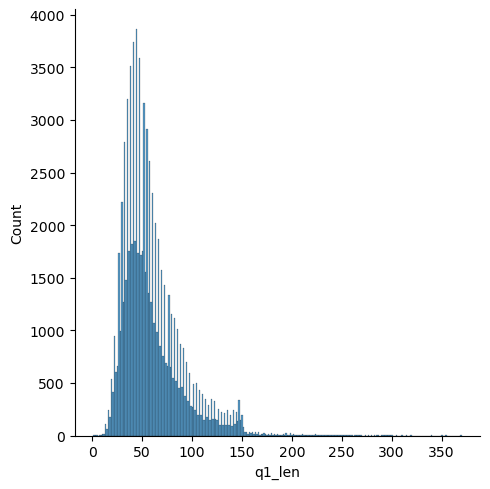

In [42]:
# Analysis of features
sns.displot(new_df['q1_len'])
print('minimum characters',new_df['q1_len'].min())
print('maximum characters',new_df['q1_len'].max())
print('average num of characters',int(new_df['q1_len'].mean()))

In [43]:
new_df.columns

Index(['id', 'qid1', 'qid2', 'question1', 'question2', 'is_duplicate',
       'q1_len', 'q2_len', 'q1_num_words', 'q2_num_words', 'word_common',
       'unique_words_total', 'word_share'],
      dtype='object')

In [44]:
l=['q1_len', 'q2_len', 'q1_num_words', 'q2_num_words', 'word_common',
       'unique_words_total', 'word_share']

minimum characters 1
maximum characters 370
average num of characters 59
******************************
minimum characters 2
maximum characters 1169
average num of characters 60
******************************
minimum characters 1
maximum characters 73
average num of characters 10
******************************
minimum characters 1
maximum characters 237
average num of characters 11
******************************
minimum characters 0
maximum characters 31
average num of characters 4
******************************
minimum characters 3
maximum characters 166
average num of characters 21
******************************
minimum characters 0.0
maximum characters 0.5
average num of characters 0
******************************


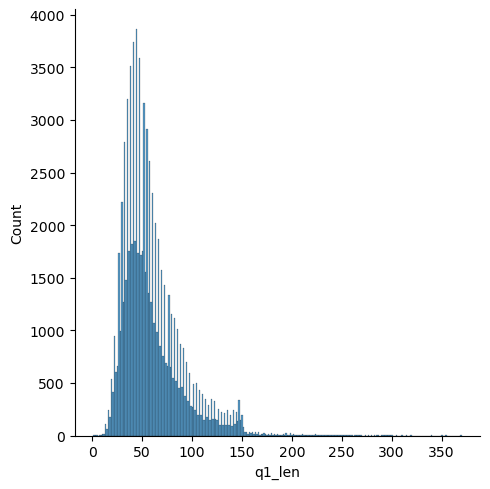

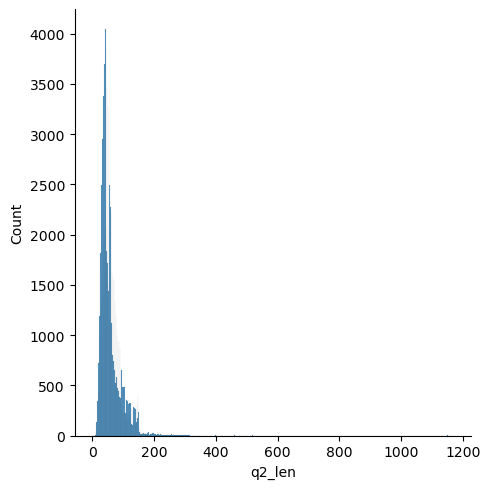

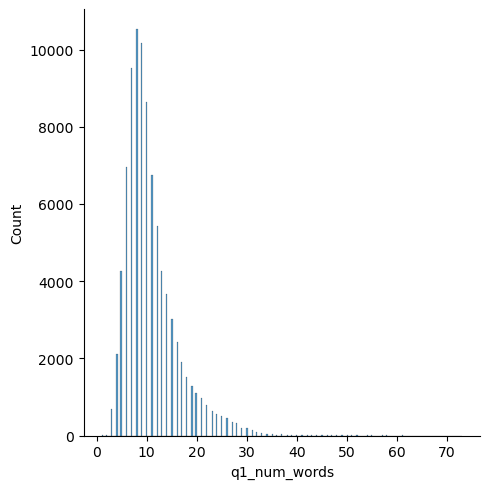

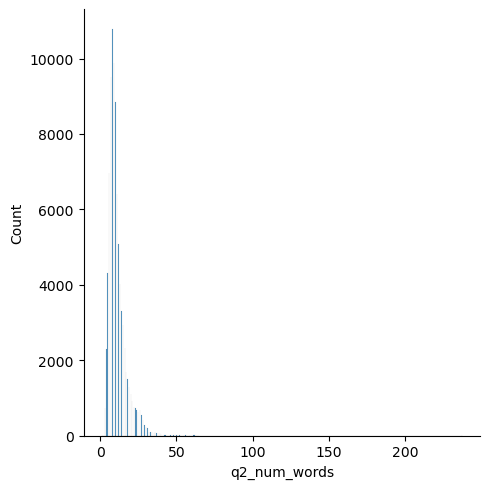

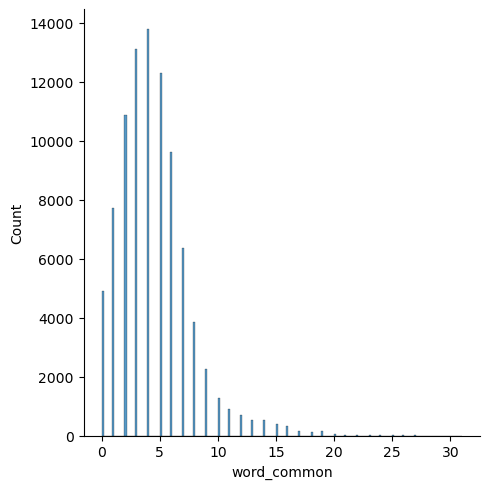

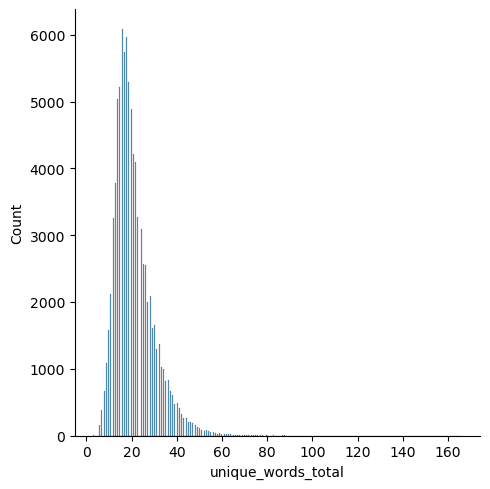

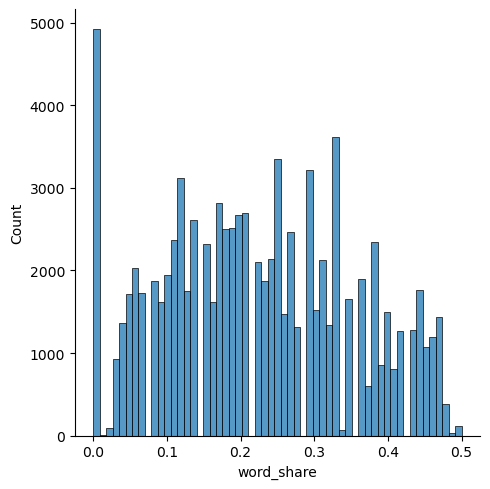

In [45]:
for i in l:
    sns.displot(new_df[i])
    print('minimum characters',new_df[i].min())
    print('maximum characters',new_df[i].max())
    print('average num of characters',int(new_df[i].mean()))

    print("******************************")

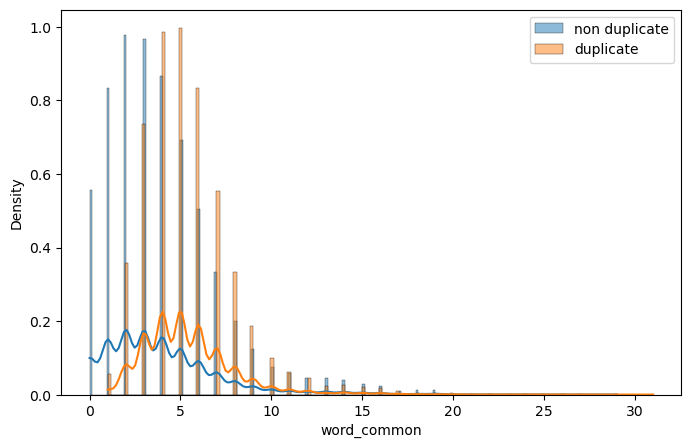

In [46]:
# common words
plt.figure(figsize=(8,5))

sns.histplot(
    new_df[new_df['is_duplicate']==0]['word_common'],
    label='non duplicate',
    kde=True,
    stat='density'
)

sns.histplot(
    new_df[new_df['is_duplicate']==1]['word_common'],
    label='duplicate',
    kde=True,
    stat='density'
)

plt.legend()
plt.show()

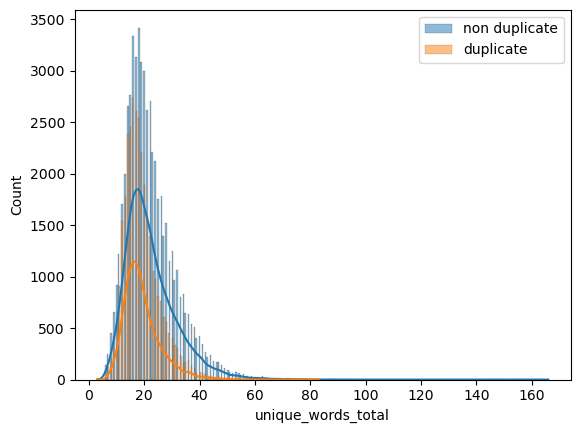

In [54]:
# total words
sns.histplot(new_df[new_df['is_duplicate'] == 0]['unique_words_total'],label='non duplicate',kde=True)
sns.histplot(new_df[new_df['is_duplicate'] == 1]['unique_words_total'],label='duplicate',kde=True)
plt.legend()
plt.show()

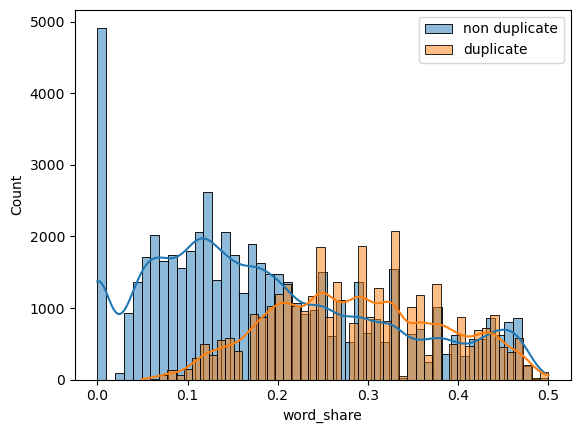

In [60]:
# word share
sns.histplot(new_df[new_df['is_duplicate'] == 0]['word_share'],label='non duplicate',kde=True)
sns.histplot(new_df[new_df['is_duplicate'] == 1]['word_share'],label='duplicate',kde=True)
plt.legend()
plt.show()

In [76]:
custom_df=new_df.drop(columns=['id','qid1','qid2','question1','question2'])

In [78]:
custom_df.shape

(89999, 8)

In [88]:
temp_df.shape

(89999, 6001)

In [90]:
temp_df.columns

Index([             0,              1,              2,              3,
                    4,              5,              6,              7,
                    8,              9,
       ...
                 2991,           2992,           2993,           2994,
                 2995,           2996,           2997,           2998,
                 2999, 'is_duplicate'],
      dtype='object', length=6001)

In [92]:
temp_df=temp_df.drop(columns=['is_duplicate'])

In [94]:
temp_df.columns

Index([   0,    1,    2,    3,    4,    5,    6,    7,    8,    9,
       ...
       2990, 2991, 2992, 2993, 2994, 2995, 2996, 2997, 2998, 2999],
      dtype='object', length=6000)

In [96]:
temp_df.shape

(89999, 6000)

In [98]:
final_df = pd.concat([custom_df, temp_df], axis=1)
print(final_df.shape)
final_df.head()

(89999, 6008)


,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common,unique_words_total,word_share,0,1,...,2990,2991,2992,2993,2994,2995,2996,2997,2998,2999
229414,1,125,64,20,12,8,31,0.26,0,0,...,0,0,0,0,0,0,0,0,0,0
234789,0,127,72,24,14,6,36,0.17,0,0,...,0,0,0,0,0,0,0,0,0,0
171597,0,67,54,13,11,7,24,0.29,0,0,...,0,0,0,0,0,0,0,0,0,0
90513,0,25,46,6,9,0,15,0.00,0,0,...,0,0,0,0,0,0,0,0,0,0
100505,0,69,126,11,22,1,31,0.03,0,0,...,0,1,0,0,0,0,0,0,0,0


# Train_Test_Split

In [100]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(final_df.iloc[:,1:].values,final_df.iloc[:,0].values,test_size=0.2,random_state=1)

In [101]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
rf = RandomForestClassifier()
rf.fit(X_train,y_train)
y_pred = rf.predict(X_test)
accuracy_score(y_test,y_pred)

0.7889444444444444

In [102]:
from xgboost import XGBClassifier
xgb = XGBClassifier()
xgb.fit(X_train,y_train)
y_pred = xgb.predict(X_test)
accuracy_score(y_test,y_pred)

0.7739444444444444

# Conclusion

After adding the 7 engineered features to the existing Bag-of-Words features, the model accuracy increased from 77.32% to 78.89%. This improvement shows that the additional features capture important information about question similarity and enhance the model's ability to identify duplicate questions.

-----

----

# Future work

Advanced Features

1. Token Features

- cwc_min: This is the ratio of the number of common words to the length of the smaller question
- cwc_max: This is the ratio of the number of common words to the length of the larger question
- csc_min: This is the ratio of the number of common stop words to the smaller stop word count among the two questions
- csc_max: This is the ratio of the number of common stop words to the larger stop word count among the two questions
- ctc_min: This is the ratio of the number of common tokens to the smaller token count among the two questions
- ctc_max: This is the ratio of the number of common tokens to the larger token count among the two questions
- last_word_eq: 1 if the last word in the two questions is same, 0 otherwise
- first_word_eq: 1 if the first word in the two questions is same, 0 otherwise

2. Length Based Features

- mean_len: Mean of the length of the two questions (number of words)
- abs_len_diff: Absolute difference between the length of the two questions (number of words)
- longest_substr_ratio: Ratio of the length of the longest substring among the two questions to the length of the smaller question

3. Fuzzy Features

- fuzz_ratio: fuzz_ratio score from fuzzywuzzy
- fuzz_partial_ratio: fuzz_partial_ratio from fuzzywuzzy
- token_sort_ratio: token_sort_ratio from fuzzywuzzy
- token_set_ratio: token_set_ratio from fuzzywuzzy